# King County House Price Analysis
**Dataset:** House sales in King County, WA (May 2014 – May 2015)  
**Goal:** Understand which features most significantly impact house price, and build a predictive model.  
**Special focus:** Properties valued at $650K and above.

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

df = pd.read_csv('data/king_county_houses.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


---
## 2. Exploratory Data Analysis

In [2]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe()

=== Data Types ===
id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

=== Missing Values ===
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

=== B

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


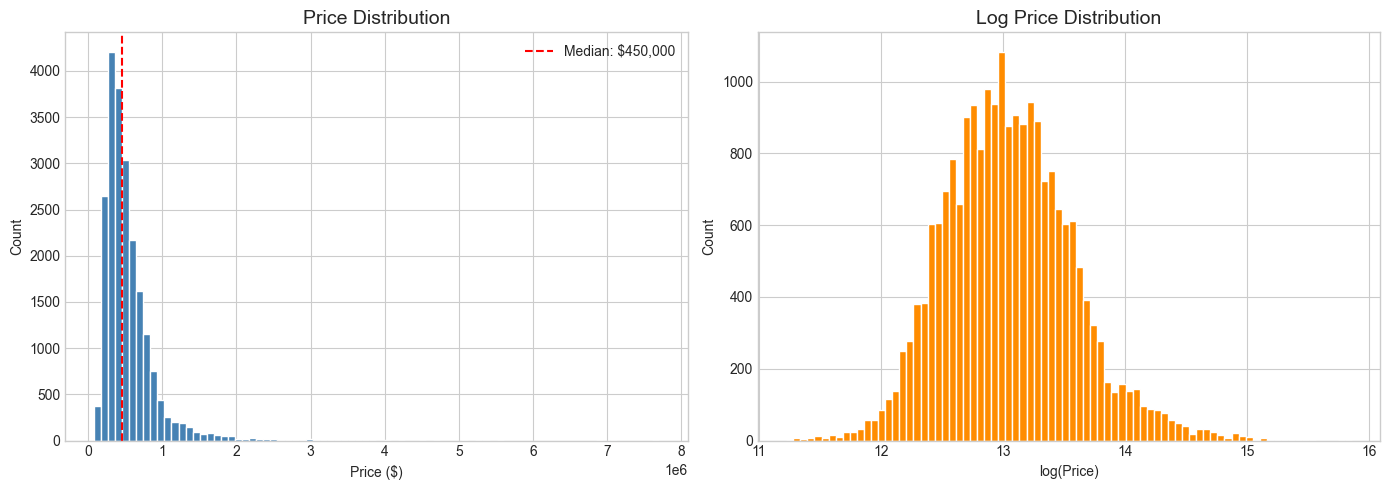

Price range: $75,000 — $7,700,000
Mean price: $540,088
Median price: $450,000


In [3]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution', fontsize=14)
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['price'].median(), color='red', linestyle='--', label=f'Median: ${df["price"].median():,.0f}')
axes[0].legend()

axes[1].hist(np.log1p(df['price']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Log Price Distribution', fontsize=14)
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('data/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Price range: ${df["price"].min():,.0f} — ${df["price"].max():,.0f}')
print(f'Mean price: ${df["price"].mean():,.0f}')
print(f'Median price: ${df["price"].median():,.0f}')

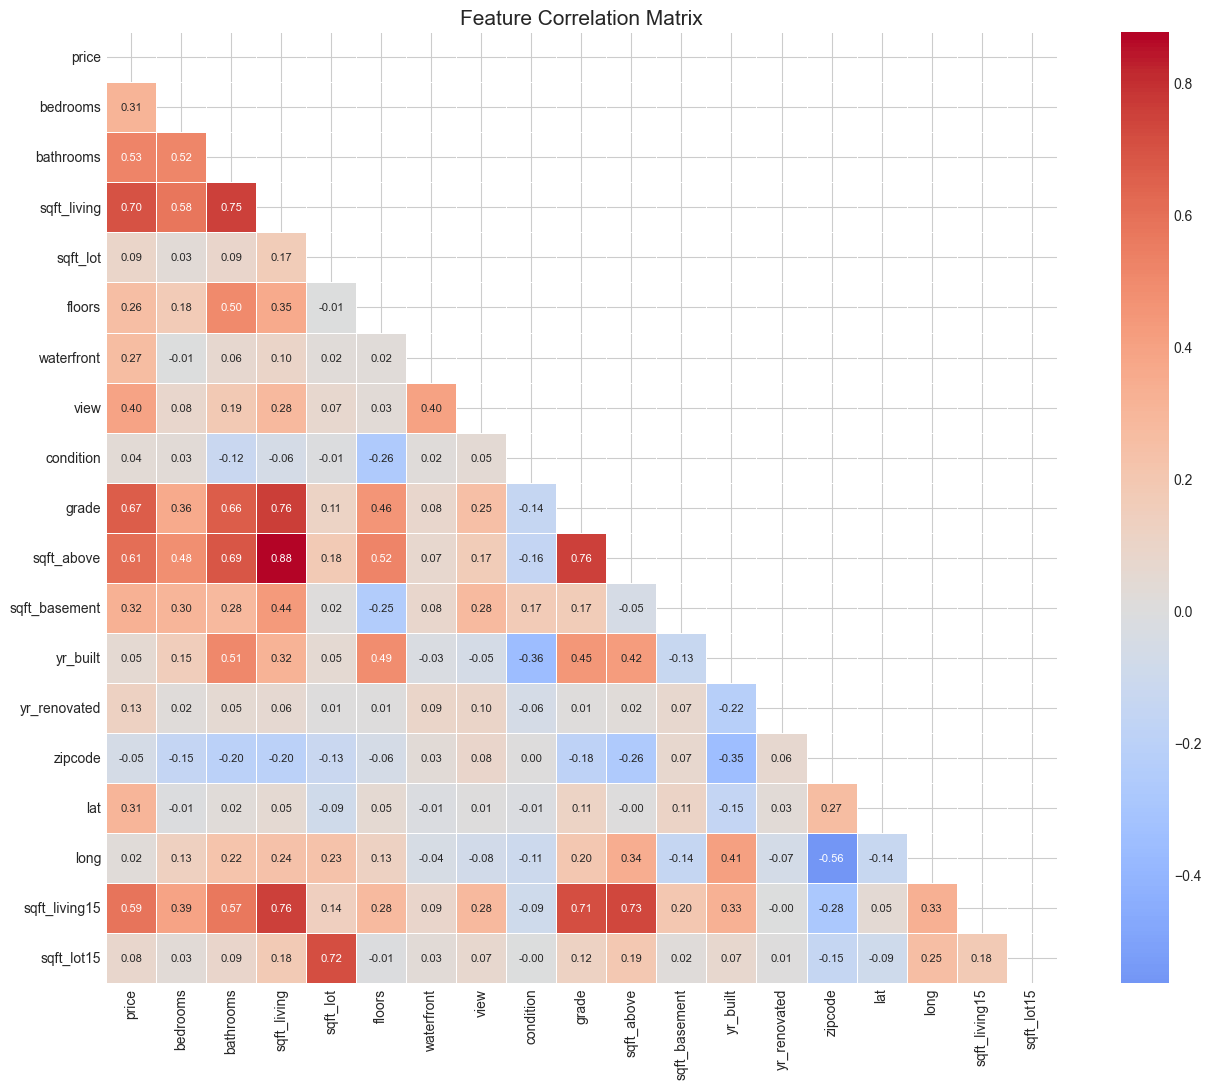

Top correlations with price:
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
Name: price, dtype: float64


In [4]:
# Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['id'])
corr_matrix = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=15)
plt.tight_layout()
plt.savefig('data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top correlations with price:')
print(corr_matrix['price'].sort_values(ascending=False).drop('price').head(10))

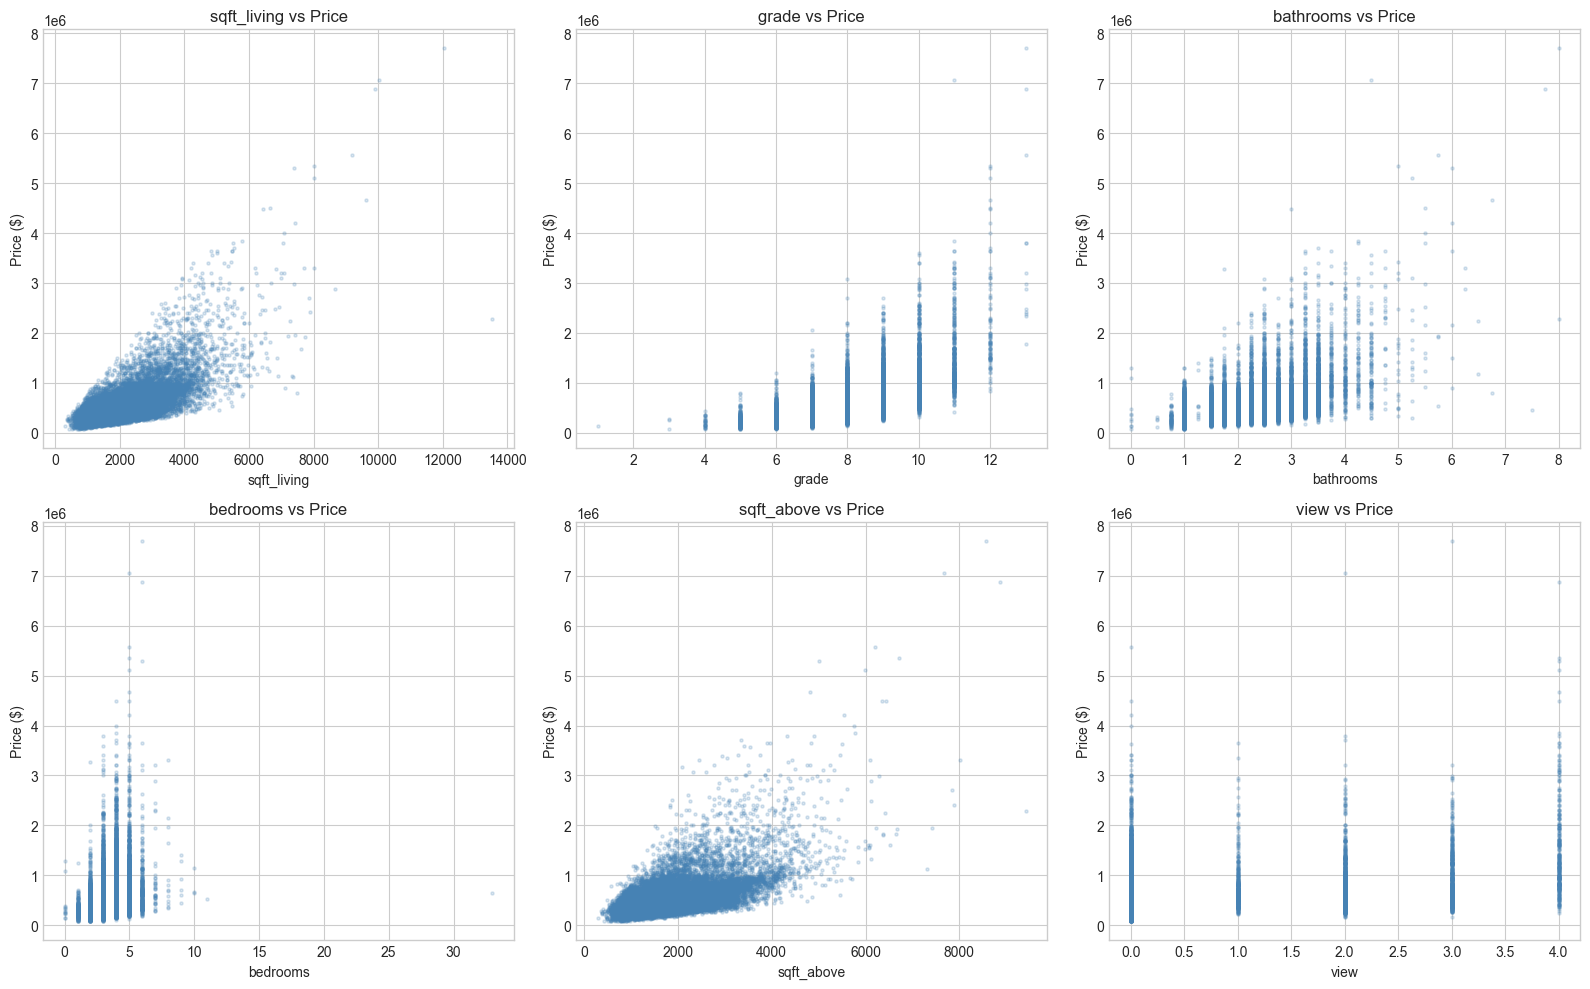

In [5]:
# Key feature relationships with price
features = ['sqft_living', 'grade', 'bathrooms', 'bedrooms', 'sqft_above', 'view']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].scatter(df[feat], df['price'], alpha=0.2, s=5, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Price ($)')
    axes[i].set_title(f'{feat} vs Price')

plt.tight_layout()
plt.savefig('data/feature_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

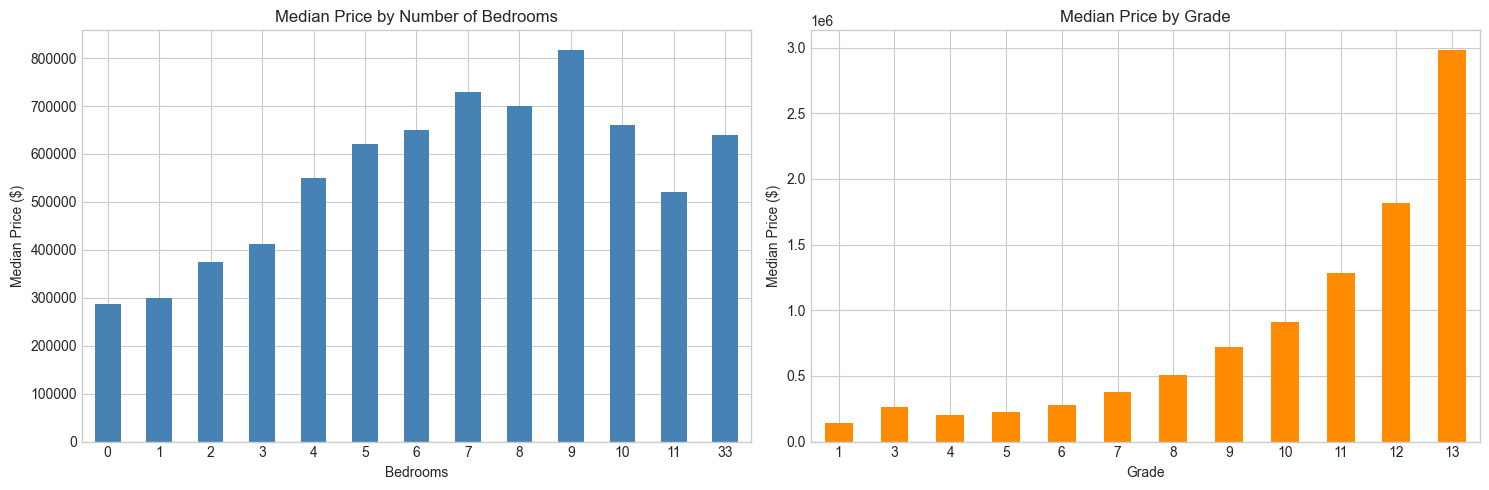

In [6]:
# Price by number of bedrooms & grade
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df.groupby('bedrooms')['price'].median().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Median Price by Number of Bedrooms')
axes[0].set_xlabel('Bedrooms')
axes[0].set_ylabel('Median Price ($)')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('grade')['price'].median().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Median Price by Grade')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Median Price ($)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('data/price_by_bedrooms_grade.png', dpi=150, bbox_inches='tight')
plt.show()

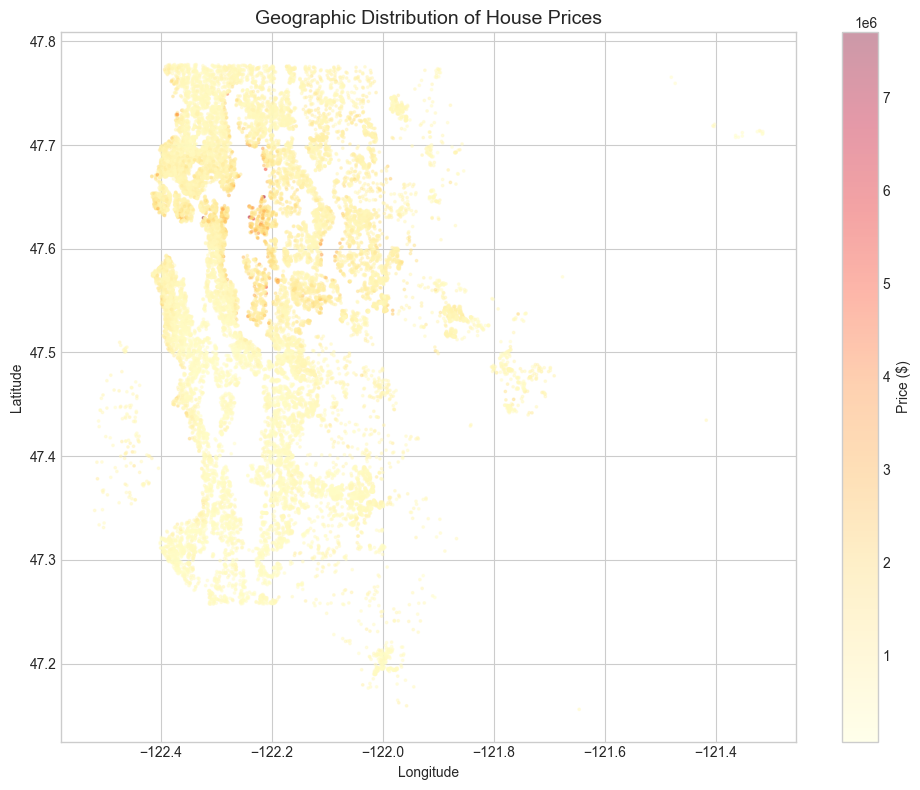

In [7]:
# Geographic distribution of prices
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(df['long'], df['lat'], c=df['price'], 
                     cmap='YlOrRd', alpha=0.4, s=3)
plt.colorbar(scatter, ax=ax, label='Price ($)')
ax.set_title('Geographic Distribution of House Prices', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('data/geographic_prices.png', dpi=150, bbox_inches='tight')
plt.show()

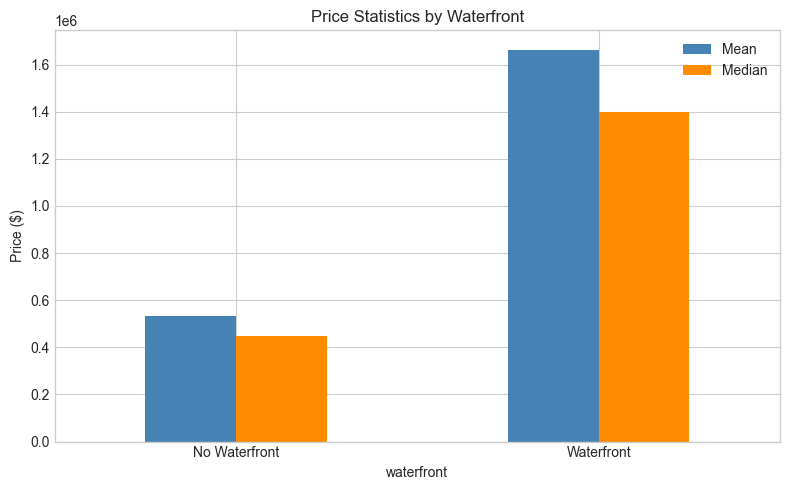


Waterfront price comparison:
                    mean     median  count
waterfront                                
0           5.315636e+05   450000.0  21450
1           1.661876e+06  1400000.0    163


In [8]:
# Waterfront impact
fig, ax = plt.subplots(figsize=(8, 5))
df.groupby('waterfront')['price'].describe()[['mean', '50%']].rename(columns={'50%': 'median'}).plot(
    kind='bar', ax=ax, color=['steelblue', 'darkorange'])
ax.set_title('Price Statistics by Waterfront')
ax.set_xticklabels(['No Waterfront', 'Waterfront'], rotation=0)
ax.set_ylabel('Price ($)')
ax.legend(['Mean', 'Median'])
plt.tight_layout()
plt.show()

print('\nWaterfront price comparison:')
print(df.groupby('waterfront')['price'].agg(['mean', 'median', 'count']))

---
## 3. Premium Properties: $650K and Above

In [9]:
premium = df[df['price'] >= 650_000].copy()
standard = df[df['price'] < 650_000].copy()

print(f'Premium properties (≥$650K): {len(premium):,} ({len(premium)/len(df)*100:.1f}% of total)')
print(f'Standard properties (<$650K): {len(standard):,} ({len(standard)/len(df)*100:.1f}% of total)')

comparison = pd.DataFrame({
    'Standard (<$650K)': standard[['price','sqft_living','bedrooms','bathrooms','grade']].mean(),
    'Premium (≥$650K)': premium[['price','sqft_living','bedrooms','bathrooms','grade']].mean()
})
print('\nMean values comparison:')
print(comparison.round(2))

Premium properties (≥$650K): 5,324 (24.6% of total)
Standard properties (<$650K): 16,289 (75.4% of total)

Mean values comparison:
             Standard (<$650K)  Premium (≥$650K)
price                392819.76         990661.89
sqft_living            1777.47           3005.20
bedrooms                  3.22              3.82
bathrooms                 1.93              2.68
grade                     7.27              8.85


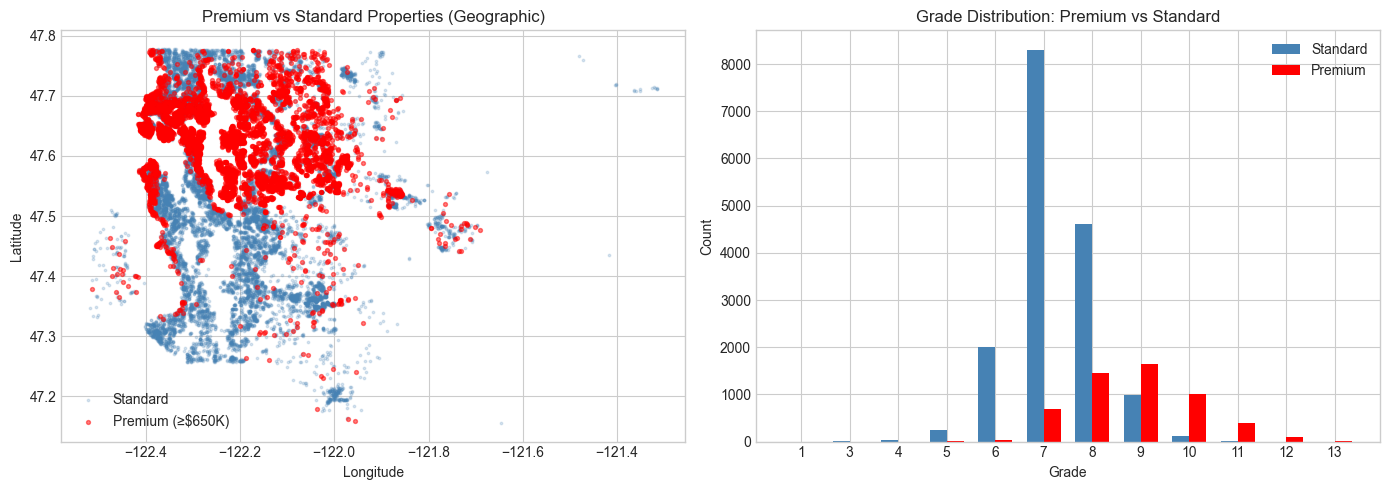

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Geographic premium vs standard
axes[0].scatter(standard['long'], standard['lat'], alpha=0.2, s=3, color='steelblue', label='Standard')
axes[0].scatter(premium['long'], premium['lat'], alpha=0.5, s=8, color='red', label='Premium (≥$650K)')
axes[0].set_title('Premium vs Standard Properties (Geographic)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend()

# Grade distribution premium vs standard
grade_std = standard['grade'].value_counts().sort_index()
grade_prem = premium['grade'].value_counts().sort_index()
x = np.arange(len(grade_std.index.union(grade_prem.index)))
width = 0.35
all_grades = sorted(grade_std.index.union(grade_prem.index))
axes[1].bar(x - width/2, [grade_std.get(g, 0) for g in all_grades], width, label='Standard', color='steelblue')
axes[1].bar(x + width/2, [grade_prem.get(g, 0) for g in all_grades], width, label='Premium', color='red')
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_grades)
axes[1].set_title('Grade Distribution: Premium vs Standard')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/premium_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Feature Engineering & Preprocessing

In [11]:
df_model = df.copy()

# Parse date and extract year/month
df_model['date'] = pd.to_datetime(df_model['date'], format='%Y%m%dT%H%M%S')
df_model['sale_year'] = df_model['date'].dt.year
df_model['sale_month'] = df_model['date'].dt.month

# House age at time of sale
df_model['house_age'] = df_model['sale_year'] - df_model['yr_built']

# Was it renovated?
df_model['was_renovated'] = (df_model['yr_renovated'] > 0).astype(int)

# Years since renovation (0 if never renovated)
df_model['years_since_renovation'] = np.where(
    df_model['yr_renovated'] > 0,
    df_model['sale_year'] - df_model['yr_renovated'],
    df_model['house_age']
)

# Price per sqft
df_model['price_per_sqft'] = df_model['price'] / df_model['sqft_living']

# Has basement
df_model['has_basement'] = (df_model['sqft_basement'] > 0).astype(int)

# Living space ratio (house vs neighbors)
df_model['living_space_ratio'] = df_model['sqft_living'] / df_model['sqft_living15'].replace(0, np.nan)
df_model['living_space_ratio'].fillna(1, inplace=True)

# Premium flag
df_model['is_premium'] = (df_model['price'] >= 650_000).astype(int)

print('New features added:')
new_feats = ['sale_year','sale_month','house_age','was_renovated','years_since_renovation',
             'price_per_sqft','has_basement','living_space_ratio','is_premium']
print(df_model[new_feats].describe().round(2))

New features added:
       sale_year  sale_month  house_age  was_renovated  \
count   21613.00    21613.00   21613.00       21613.00   
mean     2014.32        6.57      43.32           0.04   
std         0.47        3.12      29.38           0.20   
min      2014.00        1.00      -1.00           0.00   
25%      2014.00        4.00      18.00           0.00   
50%      2014.00        6.00      40.00           0.00   
75%      2015.00        9.00      63.00           0.00   
max      2015.00       12.00     115.00           1.00   

       years_since_renovation  price_per_sqft  has_basement  \
count                21613.00        21613.00      21613.00   
mean                    40.94          264.16          0.39   
std                     28.81          110.06          0.49   
min                     -1.00           87.59          0.00   
25%                     15.00          182.29          0.00   
50%                     37.00          244.64          0.00   
75%             

In [12]:
# Select features for modeling
feature_cols = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'waterfront', 'view', 'condition', 'grade', 'sqft_above',
    'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
    'lat', 'long', 'sqft_living15', 'sqft_lot15',
    'house_age', 'was_renovated', 'years_since_renovation',
    'has_basement', 'living_space_ratio', 'sale_month'
]

X = df_model[feature_cols].copy()
y = df_model['price'].copy()

# Handle any remaining nulls
X.fillna(X.median(), inplace=True)

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')

Feature matrix shape: (21613, 24)
Target shape: (21613,)


---
## 5. Model Training & Evaluation

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]:,} samples')
print(f'Test size:  {X_test.shape[0]:,} samples')

Train size: 17,290 samples
Test size:  4,323 samples


In [14]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=False):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)
    print(f'{name:35s} | RMSE: ${rmse:>12,.0f} | MAE: ${mae:>11,.0f} | R²: {r2:.4f}')
    return model, y_pred, rmse, mae, r2

print(f'{"Model":35s} | {"RMSE":>18} | {"MAE":>17} | R²')
print('-' * 85)

results = {}

# Linear Regression
lr, lr_pred, *lr_metrics = evaluate_model(
    'Linear Regression', LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test)
results['Linear Regression'] = (lr, lr_pred, lr_metrics)

# Ridge
ridge, ridge_pred, *ridge_metrics = evaluate_model(
    'Ridge (alpha=10)', Ridge(alpha=10), X_train_scaled, X_test_scaled, y_train, y_test)
results['Ridge'] = (ridge, ridge_pred, ridge_metrics)

# Lasso
lasso, lasso_pred, *lasso_metrics = evaluate_model(
    'Lasso (alpha=100)', Lasso(alpha=100), X_train_scaled, X_test_scaled, y_train, y_test)
results['Lasso'] = (lasso, lasso_pred, lasso_metrics)

# Random Forest
rf, rf_pred, *rf_metrics = evaluate_model(
    'Random Forest', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test)
results['Random Forest'] = (rf, rf_pred, rf_metrics)

# Gradient Boosting
gb, gb_pred, *gb_metrics = evaluate_model(
    'Gradient Boosting', GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
    X_train, X_test, y_train, y_test)
results['Gradient Boosting'] = (gb, gb_pred, gb_metrics)

Model                               |               RMSE |               MAE | R²
-------------------------------------------------------------------------------------
Linear Regression                   | RMSE: $     209,666 | MAE: $    126,548 | R²: 0.7092
Ridge (alpha=10)                    | RMSE: $     210,506 | MAE: $    126,808 | R²: 0.7069
Lasso (alpha=100)                   | RMSE: $     210,586 | MAE: $    126,836 | R²: 0.7067
Random Forest                       | RMSE: $     150,524 | MAE: $     73,145 | R²: 0.8501
Gradient Boosting                   | RMSE: $     143,421 | MAE: $     76,697 | R²: 0.8639


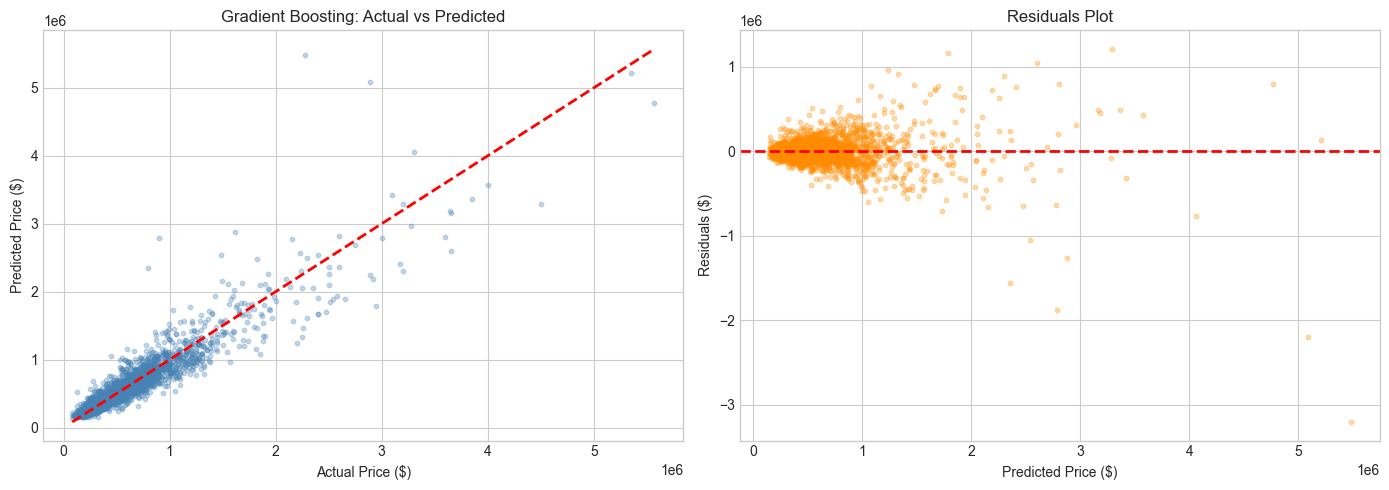

In [15]:
# Best model: Gradient Boosting - actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, gb_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Gradient Boosting: Actual vs Predicted')

# Residuals
residuals = y_test - gb_pred
axes[1].scatter(gb_pred, residuals, alpha=0.3, s=10, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residuals Plot')

plt.tight_layout()
plt.savefig('data/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

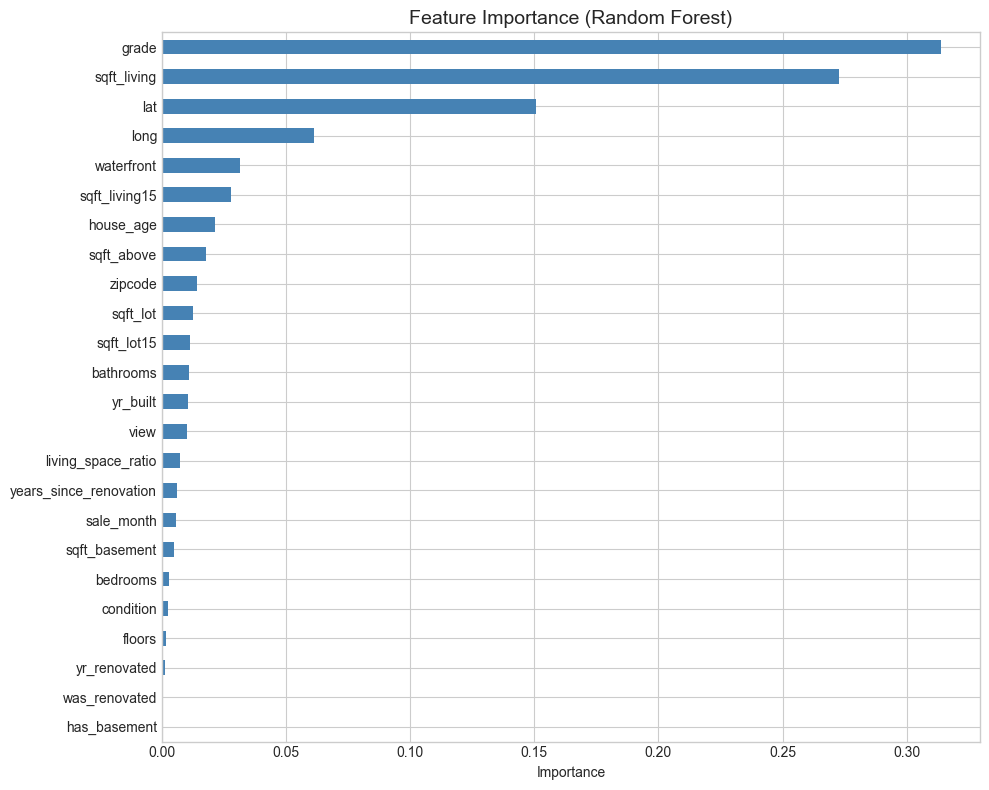

Top 10 most important features:
grade            0.313851
sqft_living      0.272737
lat              0.150740
long             0.061239
waterfront       0.031524
sqft_living15    0.027898
house_age        0.021516
sqft_above       0.017758
zipcode          0.013970
sqft_lot         0.012518
dtype: float64


In [16]:
# Feature Importance (Random Forest)
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (Random Forest)', fontsize=14)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features:')
print(feat_imp.sort_values(ascending=False).head(10))

---
## 6. Cross-Validation & Final Assessment

In [17]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model, X_data in [
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42), X)
]:
    cv_scores = cross_val_score(model, X_data, y, cv=kf, scoring='r2')
    print(f'{name}: CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Random Forest: CV R² = 0.8778 ± 0.0125
Gradient Boosting: CV R² = 0.8807 ± 0.0099


---
## 7. Key Insights Summary

In [18]:
print('=== KEY INSIGHTS ===')
print(f'''
1. DATASET
   - {len(df):,} house sales from May 2014 to May 2015
   - Price range: ${df["price"].min():,.0f} to ${df["price"].max():,.0f}
   - Median price: ${df["price"].median():,.0f}

2. TOP PRICE DRIVERS (by correlation)
   {corr_matrix["price"].drop("price").abs().sort_values(ascending=False).head(5).to_string()}

3. PREMIUM PROPERTIES (≥$650K)
   - Count: {len(premium):,} ({len(premium)/len(df)*100:.1f}% of total)
   - Mean grade: {premium["grade"].mean():.1f} vs {standard["grade"].mean():.1f} for standard
   - Mean sqft_living: {premium["sqft_living"].mean():,.0f} vs {standard["sqft_living"].mean():,.0f}
   - Waterfront rate: {premium["waterfront"].mean()*100:.1f}% vs {standard["waterfront"].mean()*100:.1f}%

4. BEST MODEL: Gradient Boosting
   - R²: {gb_metrics[2]:.4f}
   - RMSE: ${gb_metrics[0]:,.0f}
   - MAE: ${gb_metrics[1]:,.0f}
''')

=== KEY INSIGHTS ===

1. DATASET
   - 21,613 house sales from May 2014 to May 2015
   - Price range: $75,000 to $7,700,000
   - Median price: $450,000

2. TOP PRICE DRIVERS (by correlation)
   sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138

3. PREMIUM PROPERTIES (≥$650K)
   - Count: 5,324 (24.6% of total)
   - Mean grade: 8.8 vs 7.3 for standard
   - Mean sqft_living: 3,005 vs 1,777
   - Waterfront rate: 2.5% vs 0.2%

4. BEST MODEL: Gradient Boosting
   - R²: 0.8639
   - RMSE: $143,421
   - MAE: $76,697

